# NHTSA complaints - one row per complaint, a label space, and a split that survives its own checks

**Arkon Manufacturing AI | Module: NLP Text Classification | Department: Field Quality**

Notebook 01 established four things this one has to act on. The file carries 51
fields rather than the published 49. Two `read_csv` defaults corrupt it silently.
The row is not the complaint, and every one of the 126,885 extra rows repeats its
complaint's narrative byte for byte. And the component column is two labellings
joined on 2020-11-04.

This notebook turns that into a modelling table. Every exclusion it makes is counted
and printed, because the interesting number about a filtered dataset is what it threw
away, not what it kept.

The four design decisions behind it were settled before any of this was written:
the target is the top-level component segment on vehicle complaints with the
non-component values removed, the label is a set rather than one value, the window
starts at the taxonomy seam, and the split is temporal.

In [1]:
import sys
from pathlib import Path

_nb_root = Path('../..').resolve()
if str(_nb_root) not in sys.path:
    sys.path.insert(0, str(_nb_root))

from utils.arkon_utils import save_figure

print('arkon_utils loaded')

arkon_utils loaded


## 1. Imports and configuration

In [2]:
import csv
import json
import re
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = Path('../../..').resolve()
DATA = REPO_ROOT / 'data' / '07_nhtsa_complaints'
RAW = DATA / 'raw' / 'COMPLAINTS_RECEIVED_2020-2024' / 'COMPLAINTS_RECEIVED_2020-2024.txt'
PROCESSED = DATA / 'processed'
PROCESSED.mkdir(parents=True, exist_ok=True)

# The four rules this notebook applies. Declared here, before anything is measured, so
# none of them can be chosen to flatter a number further down.
MIN_NARRATIVE_CHARS = 30      # below this the text cannot describe a fault
MIN_TRAIN_COMPLAINTS = 500    # a class the training window cannot support is not a class
SELECTION_FROM = '20230701'   # threshold calibration, never fitted on
TEST_FROM = '20240101'        # held out, scored once

# Values that occupy the component column without naming a component.
NON_COMPONENT = {'UNKNOWN OR OTHER', 'NONE', 'Other/I am not sure', ''}

pd.set_option('display.width', 170)
pd.set_option('display.max_columns', 40)
print(f'raw file: {RAW.relative_to(REPO_ROOT).as_posix()}')

raw file: data/07_nhtsa_complaints/raw/COMPLAINTS_RECEIVED_2020-2024/COMPLAINTS_RECEIVED_2020-2024.txt


## 2. Read the file the way notebook 01 established it has to be read

In [3]:
NHTSA_COLUMNS = [
    'CMPLID', 'ODINO', 'MFR_NAME', 'MAKETXT', 'MODELTXT', 'YEARTXT', 'CRASH',
    'FAILDATE', 'FIRE', 'INJURED', 'DEATHS', 'COMPDESC', 'CITY', 'STATE', 'VIN',
    'DATEA', 'LDATE', 'MILES', 'OCCURENCES', 'CDESCR', 'CMPL_TYPE', 'POLICE_RPT_YN',
    'PURCH_DT', 'ORIG_OWNER_YN', 'ANTI_BRAKES_YN', 'CRUISE_CONT_YN', 'NUM_CYLS',
    'DRIVE_TRAIN', 'FUEL_SYS', 'FUEL_TYPE', 'TRANS_TYPE', 'VEH_SPEED', 'DOT',
    'TIRE_SIZE', 'LOC_OF_TIRE', 'TIRE_FAIL_TYPE', 'ORIG_EQUIP_YN', 'MANUF_DT',
    'SEAT_TYPE', 'RESTRAINT_TYPE', 'DEALER_NAME', 'DEALER_TEL', 'DEALER_CITY',
    'DEALER_STATE', 'DEALER_ZIP', 'PROD_TYPE', 'REPAIRED_YN', 'MEDICAL_ATTN',
    'VEHICLES_TOWED_YN', 'UNNAMED_50', 'UNNAMED_51',
]
USECOLS = ['ODINO', 'MFR_NAME', 'MAKETXT', 'MODELTXT', 'YEARTXT', 'CRASH', 'FIRE',
           'INJURED', 'DEATHS', 'COMPDESC', 'DATEA', 'CDESCR', 'PROD_TYPE']

rows = pd.read_csv(RAW, sep='\t', header=None, names=NHTSA_COLUMNS, dtype=str,
                   quoting=csv.QUOTE_NONE, keep_default_na=False, na_values=[],
                   usecols=USECOLS)
rows['COMPONENT'] = rows['COMPDESC'].str.split(':').str[0].str.strip()

print(f'rows          : {len(rows):,}')
print(f'complaints    : {rows["ODINO"].nunique():,}')
assert len(rows) == 418884, 'the reader lost or invented rows'

rows          : 418,884
complaints    : 291,999


## 3. The taxonomy seam, re-derived here rather than carried across

Notebook 01 located the seam. Copying its date into this notebook as a constant would
make it a typed number, and this project has been bitten by typed numbers that stopped
being true. The same rule is applied again to the same file, and the two must agree.

In [4]:
RETIRING = 'ELECTRONIC STABILITY CONTROL (ESC)'
ARRIVING = ['FORWARD COLLISION AVOIDANCE', 'LANE DEPARTURE', 'BACK OVER PREVENTION']

esc_daily = rows[rows['COMPONENT'] == RETIRING].groupby('DATEA').size()
new_daily = rows[rows['COMPONENT'].isin(ARRIVING)].groupby('DATEA').size()
in_2020 = esc_daily[(esc_daily.index >= '20201001') & (esc_daily.index < '20210101')]
last_normal = in_2020[in_2020 >= 3].index.max()
arriving = new_daily[(new_daily.index > last_normal) & (new_daily.index < '20210101')]
CUTOVER = arriving[arriving >= 3].index.min()

print(f'last normal day for the retiring class : {last_normal}')
print(f'first day of the arriving classes      : {CUTOVER}')
assert CUTOVER == '20201104', 'the seam moved, which means the file changed'
print(f'\nwindow starts at {CUTOVER}')

last normal day for the retiring class : 20201103


first day of the arriving classes      : 20201104

window starts at 20201104


## 4. Collapse rows to complaints

One complaint, one narrative, a set of components. Section 5 of notebook 01 proved
the narrative is identical across a complaint's rows, so taking the first is not a
choice between differing texts.

In [5]:
def join_labels(series):
    return sorted(set(series))

grouped = rows.groupby('ODINO', sort=False)
complaints = pd.DataFrame({
    'datea': grouped['DATEA'].first(),
    'mfr_name': grouped['MFR_NAME'].first(),
    'make': grouped['MAKETXT'].first(),
    'model': grouped['MODELTXT'].first(),
    'model_year': grouped['YEARTXT'].first(),
    'narrative': grouped['CDESCR'].first(),
    'labels_raw': grouped['COMPONENT'].apply(join_labels),
    'prod_types': grouped['PROD_TYPE'].apply(lambda s: frozenset(s)),
    'crash': grouped['CRASH'].apply(lambda s: 'Y' in set(s)),
    'fire': grouped['FIRE'].apply(lambda s: 'Y' in set(s)),
    'injured': grouped['INJURED'].apply(lambda s: pd.to_numeric(s, errors='coerce').fillna(0).max()),
    'deaths': grouped['DEATHS'].apply(lambda s: pd.to_numeric(s, errors='coerce').fillna(0).max()),
}).reset_index().rename(columns={'ODINO': 'odino'})

complaints['month'] = complaints['datea'].str[:6]
print(f'complaints: {len(complaints):,}')
print(f'columns   : {list(complaints.columns)}')

# The narrative of a complaint is one text, and the grouping above assumed it.
recheck = rows.groupby('ODINO')['CDESCR'].nunique()
print(f'\ncomplaints whose rows disagree on the narrative: {int((recheck > 1).sum())}')
assert int((recheck > 1).sum()) == 0

complaints: 291,999
columns   : ['odino', 'datea', 'mfr_name', 'make', 'model', 'model_year', 'narrative', 'labels_raw', 'prod_types', 'crash', 'fire', 'injured', 'deaths', 'month']



complaints whose rows disagree on the narrative: 0


## 5. Five exclusions, each counted

The order matters only for the accounting, not for the result: a complaint excluded
twice is counted against the first rule that catches it.

In [6]:
ledger = []
work = complaints.copy()
start = len(work)


def drop(mask, reason):
    """Apply one exclusion and record what it cost."""
    global work
    removed = int(mask.sum())
    ledger.append((reason, removed))
    work = work[~mask].copy()
    return removed


drop(work['datea'] < CUTOVER, f'received before the taxonomy seam {CUTOVER}')
drop(work['prod_types'] != frozenset({'V'}), 'not unambiguously about a vehicle')

work['labels'] = work['labels_raw'].apply(lambda ls: sorted(set(ls) - NON_COMPONENT))
drop(work['labels'].str.len() == 0, 'no component label left after the non-component values')

work['narrative'] = work['narrative'].str.strip()
drop(work['narrative'].str.len() < MIN_NARRATIVE_CHARS,
     f'narrative shorter than {MIN_NARRATIVE_CHARS} characters')

# A narrative that points at a document this dataset does not contain describes no
# fault. It is a fixed string mapped to whatever component the filer chose, so training
# on it teaches the model an association with no evidence behind it.
normalised = work['narrative'].str.upper().str.replace(r'\s+', ' ', regex=True).str.strip(' .')
POINTERS = {'SEE ATTACHED DOCUMENT FOR COMPLAINT', 'SEE ATTACHED', 'SEE ATTACHED DOCUMENT'}
drop(normalised.isin(POINTERS), 'narrative is a pointer to a document not in the dataset')

print(f'{"exclusion":<62}{"complaints":>11}')
for reason, n in ledger:
    print(f'{reason:<62}{n:>11,}')
print(f'{"-" * 73}')
print(f'{"started with":<62}{start:>11,}')
print(f'{"kept":<62}{len(work):>11,}   ({100 * len(work) / start:.1f}%)')

exclusion                                                      complaints
received before the taxonomy seam 20201104                         50,170
not unambiguously about a vehicle                                   3,908
no component label left after the non-component values             17,649
narrative shorter than 30 characters                                1,940
narrative is a pointer to a document not in the dataset               611
-------------------------------------------------------------------------
started with                                                      291,999
kept                                                              217,721   (74.6%)


## 6. The split, temporal and declared before the class floor

Three windows. The model is fitted on the first, its operating point is calibrated on
the second, and the third is scored once. All three are contiguous in time, which is
the only arrangement that answers the question a deployed module faces: it is fitted
on the past and it meets the future.

In [7]:
def assign_split(date):
    if date >= TEST_FROM:
        return 'test'
    if date >= SELECTION_FROM:
        return 'selection'
    return 'train'


work['split'] = work['datea'].map(assign_split)
counts = work['split'].value_counts()
print(f'{"split":<12}{"complaints":>12}{"from":>10}{"to":>10}')
for name in ['train', 'selection', 'test']:
    part = work[work['split'] == name]
    print(f'{name:<12}{len(part):>12,}{part["datea"].min():>10}{part["datea"].max():>10}')

split         complaints      from        to
train            127,213  20201104  20230630
selection         29,824  20230701  20231231
test              60,684  20240101  20241231


## 7. The class floor, measured on the training window alone

A floor read off the whole dataset would let the held-out year decide which classes
exist, which is the test set choosing the task. It is measured on train only.

In [8]:
train_labels = Counter()
for labs in work[work['split'] == 'train']['labels']:
    train_labels.update(labs)

all_labels = Counter()
for labs in work['labels']:
    all_labels.update(labs)

KEPT_CLASSES = sorted(name for name, n in train_labels.items() if n >= MIN_TRAIN_COMPLAINTS)
dropped_classes = sorted(set(all_labels) - set(KEPT_CLASSES))

print(f'classes present anywhere            : {len(all_labels)}')
print(f'classes with >= {MIN_TRAIN_COMPLAINTS} train complaints : {len(KEPT_CLASSES)}')
print(f'classes below the floor             : {len(dropped_classes)}, '
      f'holding {sum(all_labels[c] for c in dropped_classes):,} label instances between them')
print('\nbelow the floor:')
for name in sorted(dropped_classes, key=lambda c: -all_labels[c]):
    print(f'  {all_labels[name]:>6}  {name}  (train {train_labels.get(name, 0)})')

classes present anywhere            : 44
classes with >= 500 train complaints : 24
classes below the floor             : 20, holding 3,102 label instances between them

below the floor:
     780  FUEL SYSTEM, DIESEL  (train 415)
     471  SERVICE BRAKES, AIR  (train 311)
     424  ELECTRONIC STABILITY CONTROL (ESC)  (train 150)
     297  TIRES  (train 176)
     243  PARKING BRAKE  (train 136)
     240  HYBRID PROPULSION SYSTEM  (train 164)
     166  TRAILER HITCHES  (train 133)
     141  TRACTION CONTROL SYSTEM  (train 82)
     127  FIRERELATED  (train 82)
      73  FUEL SYSTEM, OTHER  (train 47)
      47  COMMUNICATION  (train 41)
      31  INTERIOR LIGHTING  (train 21)
      28  EQUIPMENT ADAPTIVE/MOBILITY  (train 20)
      24  SERVICE BRAKES, ELECTRIC  (train 9)
       4  CHILD SEAT  (train 1)
       2  ELECTRONIC STABILITY CONTROL  (train 2)
       1  COMMUNICATIONS  (train 1)
       1  Chest Clip, Buckle, Harness  (train 1)
       1  ROLLOVER  (train 1)
       1  Tether, Lower Anc

In [9]:
# A label below the floor is removed from the complaint. A complaint left with nothing
# leaves the table, and that count is part of the ledger rather than a footnote.
work['labels'] = work['labels'].apply(lambda ls: [l for l in ls if l in KEPT_CLASSES])
orphaned = int((work['labels'].str.len() == 0).sum())
ledger.append(('every label below the class floor', orphaned))
work = work[work['labels'].str.len() > 0].copy()
print(f'complaints left with no label after the floor: {orphaned:,}')
print(f'complaints remaining: {len(work):,}')

complaints left with no label after the floor: 1,629
complaints remaining: 216,092


## 8. Duplicate narratives across the split boundary

Notebook 01 found 939 narratives filed under more than one complaint id, 247 of those
groups spanning more than one year. Splitting on the date does not separate them: a
group with members in 2023 and 2024 puts text the model has already read into the
held-out year. The complaint id, which fixes the much larger within-complaint
duplication, does nothing here either.

In [10]:
first_split = work.groupby('narrative')['split'].transform('first')
group_size = work.groupby('narrative')['odino'].transform('size')
spans = work.groupby('narrative')['split'].nunique()
straddling = spans[spans > 1]

print(f'distinct narratives in the table        : {work["narrative"].nunique():,}')
print(f'narratives under more than one complaint: {int((group_size > 1).sum()):,} rows')
print(f'narratives spanning more than one split : {len(straddling):,}')

distinct narratives in the table        : 214,444
narratives under more than one complaint: 2,466 rows
narratives spanning more than one split : 179


In [11]:
# The copy that is removed is the later one. Removing the earlier copy instead would
# leave the model unfitted on text it would genuinely have seen by then, and removing
# the whole group costs training data to fix a problem that only exists downstream.
SPLIT_ORDER = {'train': 0, 'selection': 1, 'test': 2}
work['_rank'] = work['split'].map(SPLIT_ORDER)
earliest = work.groupby('narrative')['_rank'].transform('min')
leaked = work['_rank'] > earliest
removed_leak = int(leaked.sum())

by_split = work.loc[leaked, 'split'].value_counts().to_dict()
work = work[~leaked].drop(columns='_rank').copy()
ledger.append(('narrative already present in an earlier split', removed_leak))

print(f'later copies removed: {removed_leak:,}  {by_split}')
print('\nThis biases the held-out year: it now under-represents template and campaign')
print('complaints, which are exactly the repeated ones. The model card records that as')
print('a limitation rather than presenting the split as clean.')

later copies removed: 362  {'test': 323, 'selection': 39}

This biases the held-out year: it now under-represents template and campaign
complaints, which are exactly the repeated ones. The model card records that as
a limitation rather than presenting the split as clean.


In [12]:
# The check that has to pass, stated as the question rather than as a hope.
train_narratives = set(work[work['split'] == 'train']['narrative'])
sel_narratives = set(work[work['split'] == 'selection']['narrative'])
test_narratives = set(work[work['split'] == 'test']['narrative'])

print(f'test narratives also in train     : {len(test_narratives & train_narratives)}')
print(f'test narratives also in selection : {len(test_narratives & sel_narratives)}')
print(f'selection narratives also in train: {len(sel_narratives & train_narratives)}')
assert not (test_narratives & train_narratives)
assert not (test_narratives & sel_narratives)
assert not (sel_narratives & train_narratives)

ids = work['odino']
print(f'complaint ids unique              : {ids.is_unique}')
assert ids.is_unique

test narratives also in train     : 0
test narratives also in selection : 0
selection narratives also in train: 0
complaint ids unique              : True


## 9. What the table holds, and how far the label prior still moves

Cutting at the seam removed a discontinuity. It did not remove drift, and a module
whose test year has a different label prior from its training window should say so
before it reports a score.

In [13]:
final_counts = {}
for name in ['train', 'selection', 'test']:
    c = Counter()
    for labs in work[work['split'] == name]['labels']:
        c.update(labs)
    final_counts[name] = c

table = pd.DataFrame(final_counts).fillna(0).astype(int)
sizes = work['split'].value_counts()
for name in table.columns:
    table[f'{name}_%'] = 100 * table[name] / sizes[name]
table = table.sort_values('train', ascending=False)
table['drift'] = (table['test_%'] + 0.01) / (table['train_%'] + 0.01)
print(table[['train', 'selection', 'test', 'train_%', 'test_%', 'drift']].round(2).to_string())

                             train  selection   test  train_%  test_%  drift
ENGINE                       28364       7083  14059    22.48   23.42   1.04
ELECTRICAL SYSTEM            24395       5640  11475    19.34   19.11   0.99
POWER TRAIN                  18779       4344   9199    14.89   15.32   1.03
STEERING                     13677       3501   5970    10.84    9.94   0.92
SERVICE BRAKES               11947       3122   5788     9.47    9.64   1.02
AIR BAGS                      8791       2105   3676     6.97    6.12   0.88
FUEL/PROPULSION SYSTEM        8361       1979   4275     6.63    7.12   1.07
FORWARD COLLISION AVOIDANCE   7933       1939   3751     6.29    6.25   0.99
STRUCTURE                     7324       1831   3582     5.81    5.97   1.03
SUSPENSION                    6501        966   1933     5.15    3.22   0.63
VEHICLE SPEED CONTROL         5495       1328   2472     4.36    4.12   0.95
EXTERIOR LIGHTING             5028        932   1943     3.99    3.24   0.81

In [14]:
print(f'complaints per split: {sizes.to_dict()}')
per_labels = work['labels'].str.len().value_counts().sort_index()
print(f'labels per complaint: {per_labels.to_dict()}')
print(f'label instances     : {int(work["labels"].str.len().sum()):,}')
print(f'mean labels         : {work["labels"].str.len().mean():.3f}')
print(f'\nlargest drift up  : {table["drift"].idxmax()} at {table["drift"].max():.2f}x')
print(f'largest drift down: {table["drift"].idxmin()} at {table["drift"].min():.2f}x')
print(f'classes whose test share differs from train by more than 50%: '
      f'{int(((table["drift"] > 1.5) | (table["drift"] < 0.667)).sum())} of {len(table)}')

complaints per split: {'train': 126154, 'test': 60039, 'selection': 29537}
labels per complaint: {1: 156916, 2: 40171, 3: 18641, 4: 2}
label instances     : 293,189
mean labels         : 1.359

largest drift up  : ENGINE AND ENGINE COOLING at 2.72x
largest drift down: SUSPENSION at 0.63x
classes whose test share differs from train by more than 50%: 7 of 24


## 10. Narrative length and manufacturer coverage, which the trend detector needs

In [15]:
work['narrative_chars'] = work['narrative'].str.len()
work['narrative_words'] = work['narrative'].str.split().str.len()
print(work[['narrative_chars', 'narrative_words']].describe(
    percentiles=[.05, .5, .95]).round(1).to_string())

mfr = work['mfr_name'].value_counts()
print(f'\ndistinct manufacturers: {len(mfr):,}')
cum = mfr.cumsum() / mfr.sum()
for k in (10, 25, 50, 100):
    if k <= len(mfr):
        print(f'  top {k:>3} cover {100 * cum.iloc[k - 1]:.2f}% of complaints')
print('largest: ' + ', '.join(f'{n[:28]}={v:,}' for n, v in mfr.head(5).items()))

       narrative_chars  narrative_words
count         215730.0         215730.0
mean             588.6            103.0
std              417.1             74.6
min               30.0              1.0
5%                92.0             16.0
50%              507.0             87.0
95%             1481.0            265.0
max             2048.0            430.0

distinct manufacturers: 258
  top  10 cover 87.39% of complaints
  top  25 cover 98.55% of complaints
  top  50 cover 99.60% of complaints
  top 100 cover 99.89% of complaints
largest: Ford Motor Company=44,770, Chrysler (FCA US, LLC)=29,917, General Motors, LLC=28,017, Honda (American Honda Motor =20,294, Hyundai Motor America=15,738


  ✓ Saved → assets\nlp\nhtsa_prep_split.png


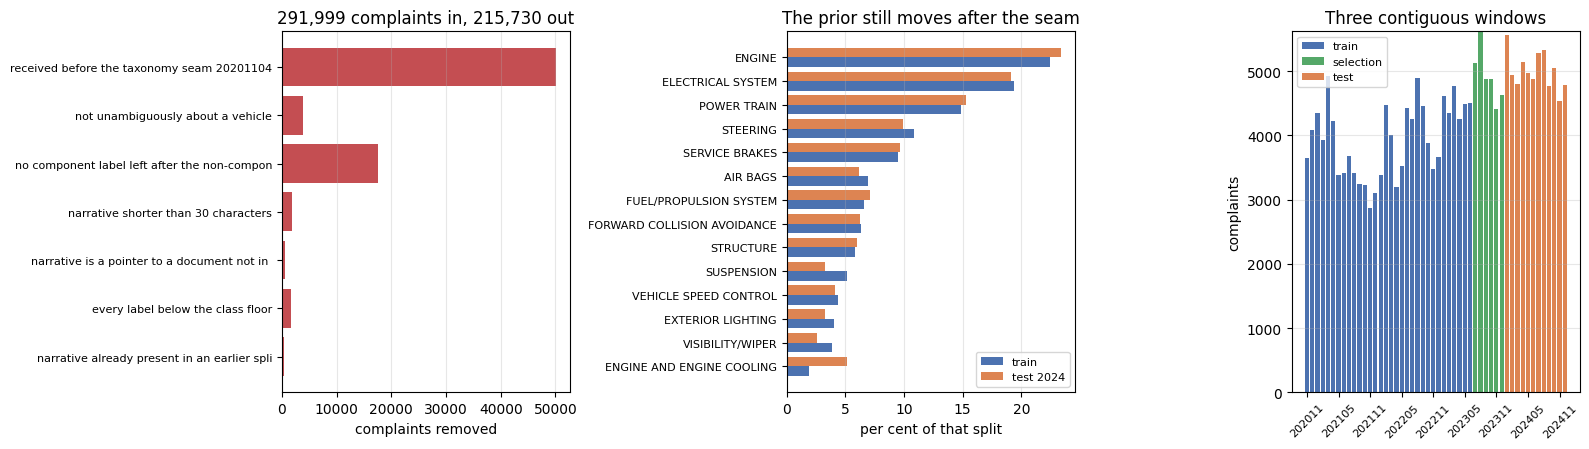

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))

ax = axes[0]
order = [r for r, _ in ledger]
vals = [n for _, n in ledger]
ax.barh(range(len(order))[::-1], vals, color='#C44E52')
ax.set_yticks(range(len(order))[::-1])
ax.set_yticklabels([r[:44] for r in order], fontsize=8)
ax.set_xlabel('complaints removed')
ax.set_title(f'{start:,} complaints in, {len(work):,} out')
ax.grid(axis='x', alpha=0.3)

ax = axes[1]
top = table.head(14)
y = np.arange(len(top))
ax.barh(y + 0.2, top['train_%'], height=0.4, label='train', color='#4C72B0')
ax.barh(y - 0.2, top['test_%'], height=0.4, label='test 2024', color='#DD8452')
ax.set_yticks(y)
ax.set_yticklabels([n[:30] for n in top.index], fontsize=8)
ax.invert_yaxis()
ax.set_xlabel('per cent of that split')
ax.set_title('The prior still moves after the seam')
ax.legend(fontsize=8)
ax.grid(axis='x', alpha=0.3)

ax = axes[2]
monthly = work.groupby(['month', 'split']).size().unstack(fill_value=0)
bottom = np.zeros(len(monthly))
for name, colour in (('train', '#4C72B0'), ('selection', '#55A868'), ('test', '#DD8452')):
    if name in monthly:
        ax.bar(range(len(monthly)), monthly[name], bottom=bottom, label=name, color=colour)
        bottom += monthly[name].values
ax.set_xticks(range(0, len(monthly), 6))
ax.set_xticklabels([monthly.index[i] for i in range(0, len(monthly), 6)], rotation=45, fontsize=8)
ax.set_ylabel('complaints')
ax.set_title('Three contiguous windows')
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
save_figure(fig, 'nhtsa_prep_split', subfolder='nlp')
plt.show()

## 11. Write the artifacts

In [17]:
SEP = '|'
assert not any(SEP in c for c in KEPT_CLASSES), 'a class name contains the join character'

out = work[['odino', 'datea', 'month', 'split', 'mfr_name', 'make', 'model',
            'model_year', 'crash', 'fire', 'injured', 'deaths',
            'narrative', 'narrative_chars', 'narrative_words']].copy()
out['labels'] = work['labels'].apply(SEP.join)
out = out.sort_values(['datea', 'odino']).reset_index(drop=True)

TABLE_PATH = PROCESSED / 'nhtsa_complaints.parquet'
out.to_parquet(TABLE_PATH, index=False)
print(f'wrote {TABLE_PATH.relative_to(REPO_ROOT).as_posix()}  '
      f'{TABLE_PATH.stat().st_size / 1e6:.1f} MB, {len(out):,} rows')

wrote data/07_nhtsa_complaints/processed/nhtsa_complaints.parquet  71.2 MB, 215,730 rows


In [18]:
drift_over_half = int(((table['drift'] > 1.5) | (table['drift'] < 0.667)).sum())
label_space = {
    'cutover': CUTOVER,
    # Facts about the raw file, recorded here because this is the last notebook that
    # reads it and the model card needs them without opening a 326 MB file.
    'raw_rows': int(len(rows)),
    'raw_complaints': int(rows['ODINO'].nunique()),
    'raw_multi_label_complaints': int((rows.groupby('ODINO')['COMPONENT'].nunique() > 1).sum()),
    'raw_narrative_double_quotes': int(rows['CDESCR'].str.contains('"').sum()),
    'drift_classes_over_half': drift_over_half,
    'drift_worst_class': str(table['drift'].idxmax()),
    'drift_worst_ratio': float(table['drift'].max()),
    'leaked_copies_removed': int(removed_leak),
    'leaked_copies_by_split': {str(k): int(v) for k, v in by_split.items()},
    'cutover_basis': ('derived: the last day with three or more rows of the retiring '
                      'class, then the first day with three or more of the arriving ones'),
    'selection_from': SELECTION_FROM,
    'test_from': TEST_FROM,
    'min_narrative_chars': MIN_NARRATIVE_CHARS,
    'min_train_complaints': MIN_TRAIN_COMPLAINTS,
    'non_component_values': sorted(NON_COMPONENT - {''}),
    'classes': KEPT_CLASSES,
    'classes_below_floor': dropped_classes,
    'exclusions': [{'reason': r, 'complaints': n} for r, n in ledger],
    'complaints_in': int(start),
    'complaints_out': int(len(out)),
    'split_sizes': {k: int(v) for k, v in sizes.items()},
    'label_counts': {name: {k: int(v) for k, v in final_counts[name].items()}
                     for name in final_counts},
}
SPACE_PATH = PROCESSED / 'nhtsa_label_space.json'
SPACE_PATH.write_text(json.dumps(label_space, indent=2), encoding='utf-8')
print(f'wrote {SPACE_PATH.relative_to(REPO_ROOT).as_posix()}')
print(f'{len(KEPT_CLASSES)} classes: ' + ', '.join(KEPT_CLASSES[:6]) + ', ...')

wrote data/07_nhtsa_complaints/processed/nhtsa_label_space.json
24 classes: AIR BAGS, BACK OVER PREVENTION, ELECTRICAL SYSTEM, ENGINE, ENGINE AND ENGINE COOLING, EQUIPMENT, ...


## 12. What this notebook produced

In [19]:
print(f'1. {len(out):,} complaints from {start:,}, one row each, sorted by receipt date.')
print(f'   {sum(n for _, n in ledger):,} were excluded and every exclusion is counted above.')
print()
print(f'2. {len(KEPT_CLASSES)} component classes, floored at {MIN_TRAIN_COMPLAINTS} training')
print(f'   complaints measured on the training window alone. {len(dropped_classes)} classes fell')
print('   below it. The label is a set: %.3f labels per complaint on average, %d at most.'
      % (work['labels'].str.len().mean(), work['labels'].str.len().max()))
print()
print(f'3. Three contiguous windows: train to {SELECTION_FROM}, selection to {TEST_FROM},')
print(f'   test {TEST_FROM} onward. {sizes["train"]:,} / {sizes["selection"]:,} / {sizes["test"]:,}.')
print()
print(f'4. {removed_leak:,} complaints were removed because their narrative had already')
print('   appeared in an earlier split. No narrative now appears in two splits, which is')
print('   asserted rather than hoped for, and the held-out year is biased against')
print('   template complaints as a result.')
print()
print('5. The label prior still drifts after the seam: %d of %d classes differ between'
      % (int(((table['drift'] > 1.5) | (table['drift'] < 0.667)).sum()), len(table)))
print('   train and test by more than half their own share, %s furthest at %.2fx.'
      % (table['drift'].idxmax()[:34], table['drift'].max()))
print('   That is the honest situation for a field-quality module and it belongs in the')
print('   performance section, not in a footnote.')

1. 215,730 complaints from 291,999, one row each, sorted by receipt date.
   76,269 were excluded and every exclusion is counted above.

2. 24 component classes, floored at 500 training
   complaints measured on the training window alone. 20 classes fell
   below it. The label is a set: 1.359 labels per complaint on average, 4 at most.

3. Three contiguous windows: train to 20230701, selection to 20240101,
   test 20240101 onward. 126,154 / 29,537 / 60,039.

4. 362 complaints were removed because their narrative had already
   appeared in an earlier split. No narrative now appears in two splits, which is
   asserted rather than hoped for, and the held-out year is biased against
   template complaints as a result.

5. The label prior still drifts after the seam: 7 of 24 classes differ between
   train and test by more than half their own share, ENGINE AND ENGINE COOLING furthest at 2.72x.
   That is the honest situation for a field-quality module and it belongs in the
   performance sec